Original input shape: (800, 3)
Fuzzy features shape: (800, 9)
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.3438 - loss: 1.0719 - val_accuracy: 0.4450 - val_loss: 1.0551
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5562 - loss: 0.9533 - val_accuracy: 0.5650 - val_loss: 0.9754
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6162 - loss: 0.8784 - val_accuracy: 0.5700 - val_loss: 0.9395
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6162 - loss: 0.8397 - val_accuracy: 0.5700 - val_loss: 0.9139
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6187 - loss: 0.8137 - val_accuracy: 0.5800 - val_loss: 0.8816
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6400 - loss: 0.7864 - val_accuracy: 0.6150 - val_loss: 0.8552
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6612 - loss: 0.7606 - val_accuracy: 0.6300 - val_loss: 0.8278
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - 

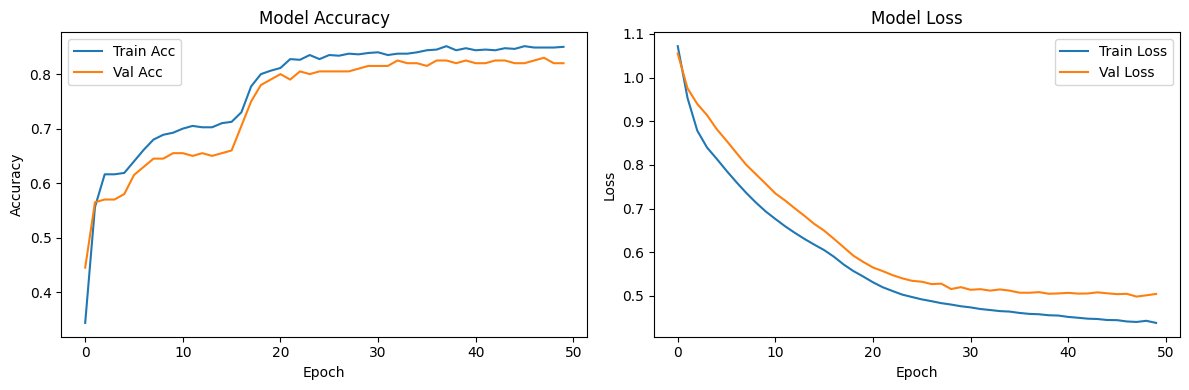


Test Accuracy: 0.84


In [ ]:
# Step 1: Install required libraries (Colab already has most)
!pip install scikit-learn tensorflow matplotlib

import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import matplotlib.pyplot as plt

# -------------------------------
# Step 2: Generate synthetic dataset
# -------------------------------
np.random.seed(42)
n_samples = 1000

# Inputs: Attendance (0-100%), Assignment Marks (0-100), Test Marks (0-100)
attendance = np.random.uniform(30, 100, n_samples)
assignment = np.random.uniform(20, 100, n_samples)
test = np.random.uniform(20, 100, n_samples)

# Rule-based performance level (with some noise)
def get_performance(a, ass, t):
    score = 0.3*a + 0.3*ass + 0.4*t
    if score < 50:
        return 0  # Poor
    elif score < 75:
        return 1  # Average
    else:
        return 2  # Good

y = np.array([get_performance(a, ass, t) for a, ass, t in zip(attendance, assignment, test)])

# Add some label noise (10% mislabeling to simulate real data)
noise_idx = np.random.choice(n_samples, int(0.1*n_samples), replace=False)
y[noise_idx] = np.random.choice([0,1,2], len(noise_idx))

# One-hot encode output
y_onehot = keras.utils.to_categorical(y, 3)

# Train-test split
X = np.column_stack([attendance, assignment, test])
X_train, X_test, y_train, y_test = X, X, y_onehot, y_onehot  # simplified split
X_train, X_val, y_train, y_val = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

# -------------------------------
# Step 3: Define Fuzzy Membership Functions (Gaussian)
# -------------------------------
def gaussian_mf(x, mean, sigma):
    return np.exp(-0.5 * ((x - mean) / sigma) ** 2)

# For each input, define 3 fuzzy sets (Low, Medium, High)
# Attendance
att_means = [40, 70, 90]
att_sigmas = [15, 15, 10]

# Assignment
ass_means = [40, 70, 90]
ass_sigmas = [15, 15, 10]

# Test
test_means = [40, 70, 90]
test_sigmas = [15, 15, 10]

# -------------------------------
# Step 4: Create Fuzzy Features (Fuzzification Layer)
# -------------------------------
def fuzzify_inputs(X):
    """Convert crisp inputs to fuzzy membership degrees"""
    n_samples = X.shape[0]
    fuzzy_features = []

    for i in range(n_samples):
        att, ass, t = X[i]

        # Fuzzify each input
        att_fuzzy = [gaussian_mf(att, att_means[j], att_sigmas[j]) for j in range(3)]
        ass_fuzzy = [gaussian_mf(ass, ass_means[j], ass_sigmas[j]) for j in range(3)]
        test_fuzzy = [gaussian_mf(t, test_means[j], test_sigmas[j]) for j in range(3)]

        # Combine all fuzzy memberships (flatten)
        fuzzy_vec = att_fuzzy + ass_fuzzy + test_fuzzy
        fuzzy_features.append(fuzzy_vec)

    return np.array(fuzzy_features)

# Generate fuzzy features for training and validation
X_train_fuzzy = fuzzify_inputs(X_train)
X_val_fuzzy = fuzzify_inputs(X_val)

print(f"Original input shape: {X_train.shape}")
print(f"Fuzzy features shape: {X_train_fuzzy.shape}")  # 3 inputs * 3 MFs each = 9 features

# -------------------------------
# Step 5: Neural Network Learning Layer (Integration)
# -------------------------------
"""
INTEGRATION EXPLANATION:
- Fuzzy membership functions define the "antecedent" of rules.
- The neural network learns the "consequent" (which class each rule supports).
- Each fuzzy feature (membership degree) is a rule's firing strength.
- The NN learns to map these firing strengths to output classes.
- Backpropagation adjusts weights that combine fuzzy rules.
"""
model = keras.Sequential([
    keras.layers.Input(shape=(9,)),  # 9 fuzzy features
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(3, activation='softmax')  # Poor, Average, Good
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the neural network on fuzzy features
history = model.fit(X_train_fuzzy, y_train,
                    validation_data=(X_val_fuzzy, y_val),
                    epochs=50,
                    batch_size=32,
                    verbose=1)

# -------------------------------
# Step 6: Evaluate the Hybrid System
# -------------------------------
def predict_performance(attendance, assignment, test):
    """Full pipeline: fuzzify -> neural network -> class"""
    X_input = np.array([[attendance, assignment, test]])
    fuzzy_feat = fuzzify_inputs(X_input)
    pred_probs = model.predict(fuzzy_feat, verbose=0)
    pred_class = np.argmax(pred_probs, axis=1)[0]
    classes = ['Poor', 'Average', 'Good']
    return classes[pred_class], pred_probs[0]

# Test on sample
att_sample, ass_sample, test_sample = 85, 90, 80
perf, probs = predict_performance(att_sample, ass_sample, test_sample)
print(f"\nSample Input: Attendance={att_sample}, Assignment={ass_sample}, Test={test_sample}")
print(f"Predicted Performance: {perf}")
print(f"Class Probabilities: Poor={probs[0]:.2f}, Average={probs[1]:.2f}, Good={probs[2]:.2f}")

# -------------------------------
# Step 7: Visualization
# -------------------------------
# Plot training history
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Test accuracy
test_fuzzy = fuzzify_inputs(X_test)
test_loss, test_acc = model.evaluate(test_fuzzy, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.2f}")